In [ ]:
!pip install utm

In [ ]:
from oauthlib.oauth2 import BackendApplicationClient
from requests_oauthlib import OAuth2Session
from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.io import MemoryFile
from rasterio import features
import requests
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt


In [ ]:
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
import utm

In [ ]:
#
CLIENT_ID = "sh-4d1652e3-ebae-4a9c-b52f-7e1ff7b67072"
CLIENT_SECRET = "iOyAjNXSWBviMI0a9eIx2Hl46WfDAfmk"

# set up credentials
client = BackendApplicationClient(client_id=CLIENT_ID)
oauth = OAuth2Session(client=client)

# get an authentication token
token = oauth.fetch_token(
    token_url='https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token',
    client_secret=CLIENT_SECRET,
    include_client_id=True
)

In [ ]:
# set area of interest and raster attributes
lat1 = 41.534618075326755
lon1 = -72.66115504877916
lat2 = 41.54733511222051
lon2 = -72.65073169454001

bbox = [lon1, lat1, lon2, lat2]

ll_1 = [lat1, lon1]
ll_2 = [lat2, lon2]

ll_toUTM1 = utm.from_latlon(ll_1[0], ll_1[1])
ll_toUTM2 = utm.from_latlon(ll_2[0], ll_2[1])

bbox_utm = [ll_toUTM1[0], ll_toUTM1[1], ll_toUTM2[0], ll_toUTM2[1]]

#set date of scan
start_date = "2026-08-01"
end_date = "2026-09-30"
collection_id = "sentinel-1-grd"

In [ ]:
evalscript =  """
//VERSION=3
function setup() {
  return {
    input: ["VV", "VH"],
    output: { bands: 2, sampleType: "float32" }
  }
}

function evaluatePixel(samples) {
  return [samples.VV, samples.VH]
}
"""
# request body/payload
json_request = {
    'input': {
        'bounds': {
            'bbox': bbox_utm,
            'properties': {
                'crs': 'http://www.opengis.net/def/crs/EPSG/0/32618'
            }
        },
        'data': [
            {
                'type': 'sentinel-1-grd',
                'dataFilter': {
                    'timeRange': {
                        'from': f'{start_date}T00:00:00Z',
                        'to': f'{end_date}T23:59:59Z'
                    },
                    "resolution": "HIGH",
                    "acquisitionMode": "IW"
                },
                "processing": {
                    "orthorectify": True,
            },
            }
        ]
    },
    'output': {
        "resx": 10,
        "resy": 10,
        'responses': [
            {
                'identifier': 'default',
                'format': {
                    'type': 'image/tiff',
                }
            }
        ]
    },
    'evalscript': evalscript
}

# Set the request URL and headers
url_request = "https://sh.dataspace.copernicus.eu/process/v1"
headers_request = {
    "Authorization": f"Bearer {token['access_token']}"
}

# Send the request
response = oauth.post(url_request, headers=headers_request, json=json_request)

print(response.status_code)
print(response.text[:500])

200
   #�    jUTM 18 North|WGS 84| x^=�{X��ۅK)E*Q"%"�~


(1, 2)
VV min/max: 0.0008272569 10.040489
VH min/max: 0.0 1.7999464
dtype: float32
shape: (144, 83)


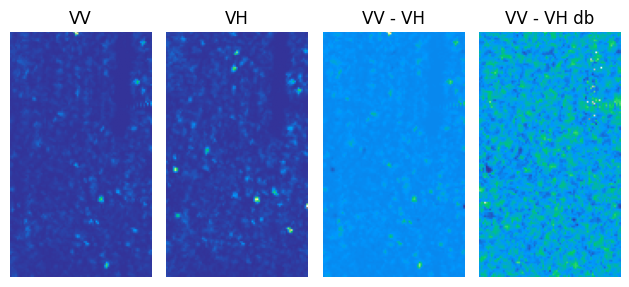

In [ ]:
# read the image rasterio array
# https://docs.sentinel-hub.com/api/latest/data/sentinel-1-grd/examples/
with MemoryFile(response.content) as memfile:
     with memfile.open() as dataset:
          data_array = dataset.read()

VV = data_array[0,:,:]
VH = data_array[1,:,:]

# combine VV and VH
#The DatasetReader.read() method returns a numpy.ndarray.
df_indicies = dataset.indexes
print(df_indicies)

VV_VH = np.array(VV - VH)

print("VV min/max:", VV.min(), VV.max())
print("VH min/max:", VH.min(), VH.max())
print("dtype:", VV.dtype)
print("shape:", VV.shape)

#read as numpy array

#image_array = np.array(Image.open(io.BytesIO(response.content)))

# plot the image for visualization
# plt.figure(figsize=(8, 4))

plt.subplot(1, 4, 3)
plt.imshow(VV_VH, cmap='terrain')
plt.title("VV - VH")
plt.axis("off")

plt.subplot(1, 4, 1)
plt.imshow(VV, cmap='terrain')
plt.title("VV")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(VH, cmap='terrain')
plt.title("VH")
plt.axis("off")

# convert vv and vh to db
vvdb = 10 * np.log10(np.maximum(VV, 1e-10))
vhdb = 10 * np.log10(np.maximum(VH, 1e-10))
vv_vhdb = vvdb - vhdb

plt.subplot(1, 4, 4)
plt.imshow(vv_vhdb, cmap='terrain')
plt.title("VV - VH db")
plt.axis("off")

plt.tight_layout()
plt.show()

200


(np.float64(-0.5), np.float64(82.5), np.float64(143.5), np.float64(-0.5))

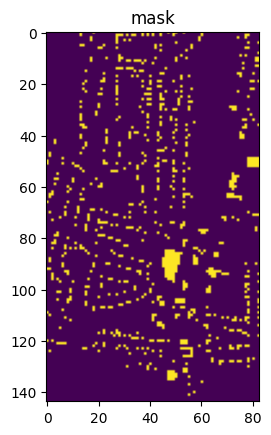

In [ ]:
#get buildings

url = ("https://services3.arcgis.com/3FL1kr7L4LvwA2Kb/arcgis/rest/services/2D_Building_Footprints/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson")

params = {
"geometry": bbox_utm,
"inSR": 32618,
"outSR": 32618,
"outFields": "*"
}

response = requests.get(url, params=params)

print(response.status_code)

df_buildings = response.json()

df_buildings = gpd.GeoDataFrame.from_features(df_buildings, crs =32618)

df_buildings.plot()

#convert to raster

building_masks = rasterio.features.rasterize(df_buildings['geometry'],
                                             out_shape= (144, 83),
                                             transform= dataset.transform,
                                             dtype='float32',
                                             fill='0')
plt.imshow(building_masks, cmap='viridis')
plt.title("mask")
plt.axis("on")


In [ ]:
# balance biased labels

X = np.column_stack([
    vvdb.ravel(),
    vhdb.ravel(),
    vv_vhdb.ravel()
])
y = building_masks.ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100,
                                       class_weight="balanced_subsample",
                                       random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

sample = X_test[0:1]
prediction = rf_classifier.predict(sample)

print(f"Predicted Survival: {'Survived' if prediction[0] == 1 else 'Did Not Survive'}")

Accuracy: 0.90

Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.98      0.95      2177
         1.0       0.25      0.06      0.09       214

    accuracy                           0.90      2391
   macro avg       0.58      0.52      0.52      2391
weighted avg       0.85      0.90      0.87      2391

Predicted Survival: Did Not Survive
